# Setup & Environment Configuration
Configure environment, paths, and load

In [10]:
# Setup & Environment Imports
import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

print(f"Project root resolved to: {PROJECT_ROOT}")

Project root resolved to: C:\Users\JYOTSNA\Documents\fiscal-ledger


# Ingest & Standardize 9 Fiscal Features

In [11]:
# Load analyzed parquet dataset and isolate percentage columns
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_analyzed.parquet"
df = pd.read_parquet(DATA_PATH)

# Define the 9 core percentage features
FEATURE_COLS = [
    'Defense_Percentage', 
    'Education_Percentage', 
    'Health_Percentage', 
    'Interest_Payments_Percentage', 
    'Infrastructure_Percentage', 
    'Agriculture_Percentage', 
    'State_Transfers_Percentage', 
    'Social_Welfare_Percentage', 
    'Administration_and_Others_Percentage'
]

# Drop rows with missing values in feature set for clean clustering
df_cluster = df.dropna(subset=FEATURE_COLS).copy()

# Standardize feature metrics (Zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[FEATURE_COLS])

print(f"Clustering matrix prepared: {X_scaled.shape[0]} observations across {X_scaled.shape[1]} features.")

Clustering matrix prepared: 3654 observations across 9 features.


# Find Optimal $K$ via Elbow & Silhouette Analysis

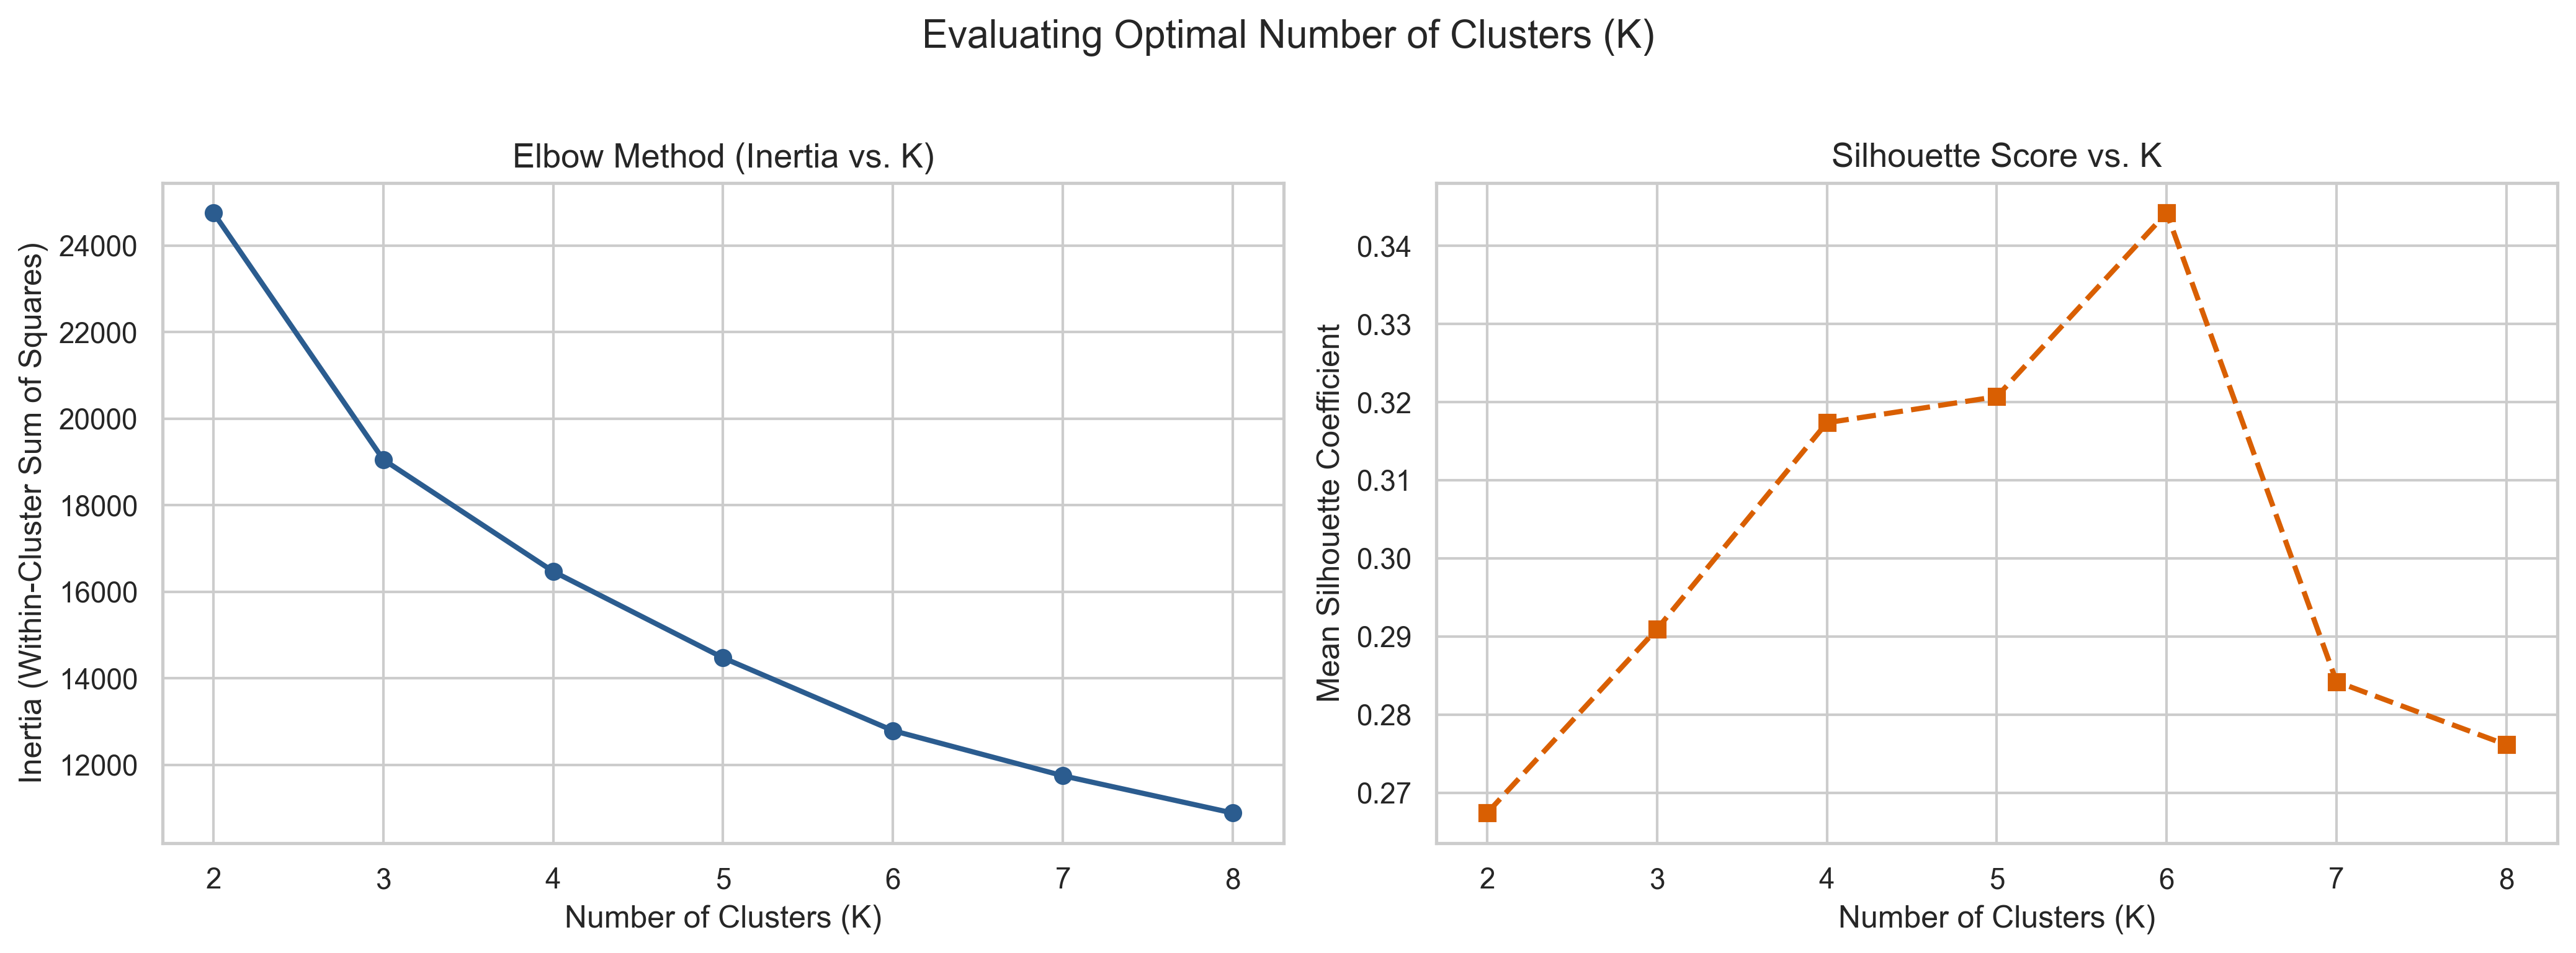

In [12]:
# Evaluate K from 2 to 8
k_range = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow and Silhouette curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax1.plot(k_range, inertias, 'o-', color='#2b5c8f', linewidth=2)
ax1.set_title("Elbow Method (Inertia vs. K)", fontsize=13)
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")

# Silhouette Score Curve
ax2.plot(k_range, silhouette_scores, 's--', color='#d95f02', linewidth=2)
ax2.set_title("Silhouette Score vs. K", fontsize=13)
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Mean Silhouette Coefficient")

plt.suptitle("Evaluating Optimal Number of Clusters (K)", fontsize=15, y=1.02)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "outputs" / "04_k_selection_diagnostics.png")
plt.show()

# Train Final K-Means ($K=4$) & Map Policy Personality Types

In [13]:
# Train KMeans model with K=4 and profile clusters
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate unstandardized mean percentage allocations per cluster
cluster_profiles = df_cluster.groupby('Cluster')[FEATURE_COLS].mean()

print("=== Raw Feature Means per Cluster (%) ===")
display(cluster_profiles.round(2))

# Map descriptive policy personality labels based on dominant spending profiles
# (Note: Verify cluster ordering on your run and adjust dict mapping accordingly)
CLUSTER_NAMES = {
    0: "Welfare States",          # Dominant Health, Education, Welfare
    1: "Security States",         # Dominant Defense
    2: "Debt-Constrained States",  # Dominant Interest Payments
    3: "Developmental States"     # Dominant Infrastructure & Agriculture
}

df_cluster['Fiscal_Personality'] = df_cluster['Cluster'].map(CLUSTER_NAMES)
print("\nAssigned Personality Distribution:")
print(df_cluster['Fiscal_Personality'].value_counts())

=== Raw Feature Means per Cluster (%) ===


,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
Cluster,,,,,,,,,
0,8.91,15.71,10.21,15.44,13.60,7.43,8.72,8.81,11.17
1,10.80,10.68,6.69,5.86,18.69,9.90,11.00,11.00,15.39
2,6.23,11.21,13.11,6.33,9.92,6.13,12.83,21.42,12.83
3,23.43,17.21,9.85,3.17,11.59,3.23,11.13,9.27,11.13



Assigned Personality Distribution:
Fiscal_Personality
Debt-Constrained States    1394
Security States             972
Welfare States              964
Developmental States        324
Name: count, dtype: int64


# Visualize Cluster Spending Profiles (Fingerprint Plot)

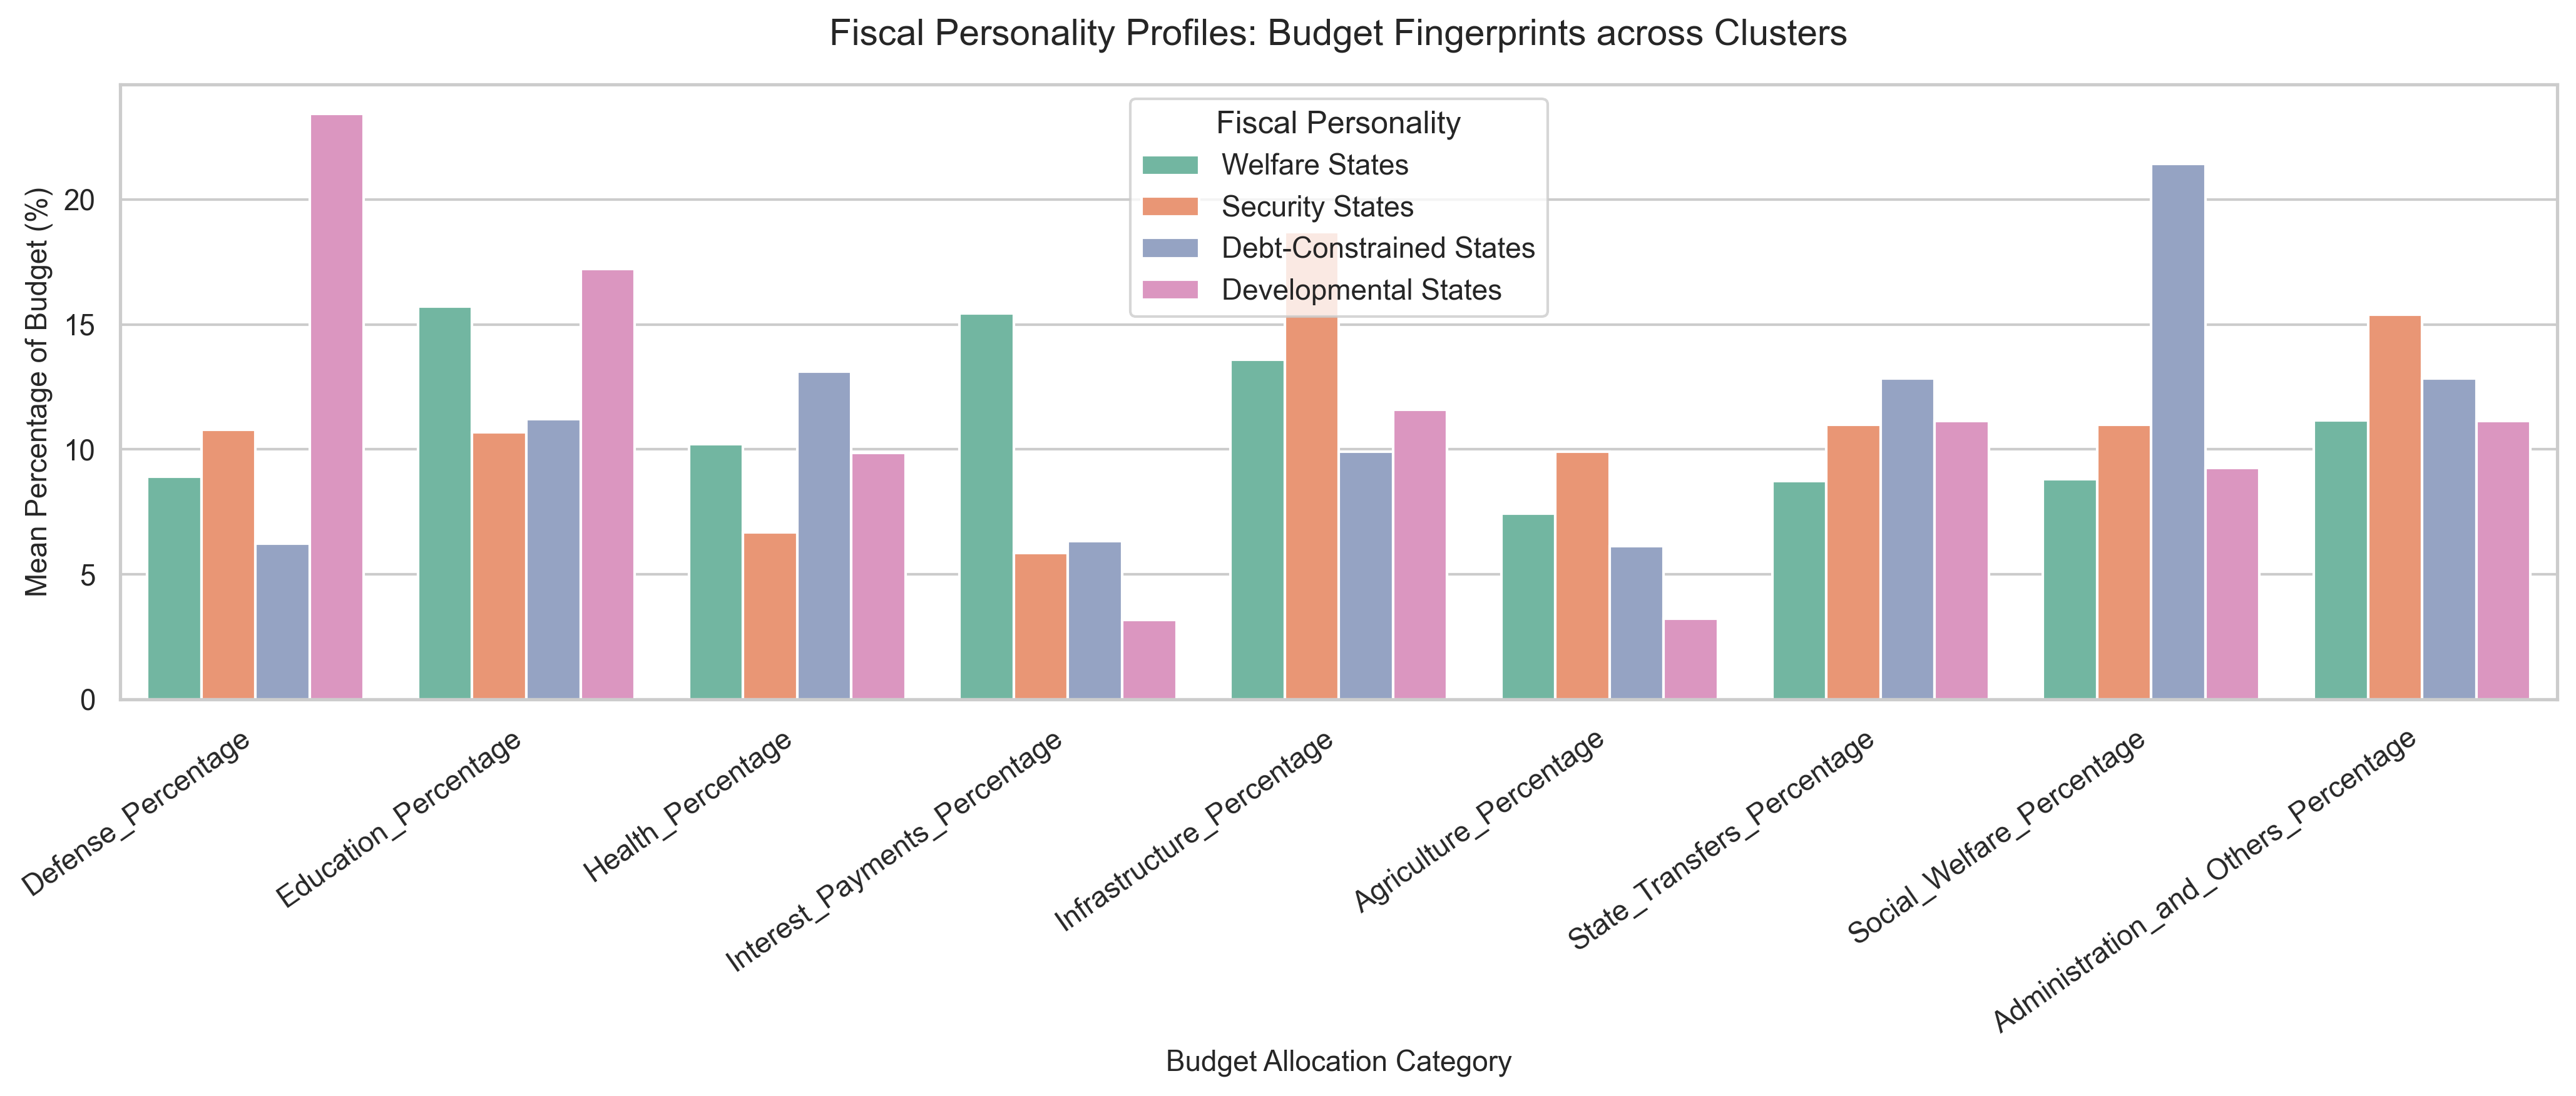

In [14]:
# Bar plot comparing the fiscal fingerprints of each personality type
profiles_melted = cluster_profiles.copy()
profiles_melted.index = profiles_melted.index.map(CLUSTER_NAMES)
profiles_melted = profiles_melted.reset_index().melt(id_vars='Cluster', var_name='Feature', value_name='Mean_Percentage')

plt.figure(figsize=(14, 6))
sns.barplot(
    data=profiles_melted, 
    x='Feature', 
    y='Mean_Percentage', 
    hue='Cluster', 
    palette='Set2'
)

plt.title("Fiscal Personality Profiles: Budget Fingerprints across Clusters", fontsize=14, pad=15)
plt.xlabel("Budget Allocation Category", fontsize=11)
plt.ylabel("Mean Percentage of Budget (%)", fontsize=11)
plt.xticks(rotation=35, ha='right')
plt.legend(title="Fiscal Personality", frameon=True)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "outputs" / "04_fiscal_personality_profiles.png")
plt.show()

# Cluster Transitions: How Nations Shift Personalities Over Decades

Tracking transitions across 45 countries with full historical coverage:


Year,1960,1995,2025
Country,,,
Argentina,Welfare States,Welfare States,Debt-Constrained States
Australia,Debt-Constrained States,Debt-Constrained States,Debt-Constrained States
Bangladesh,Security States,Welfare States,Welfare States
Brazil,Security States,Security States,Security States
Canada,Debt-Constrained States,Debt-Constrained States,Debt-Constrained States
Chile,Security States,Welfare States,Welfare States
China,Security States,Welfare States,Security States
Colombia,Welfare States,Welfare States,Welfare States
Egypt,Security States,Welfare States,Welfare States


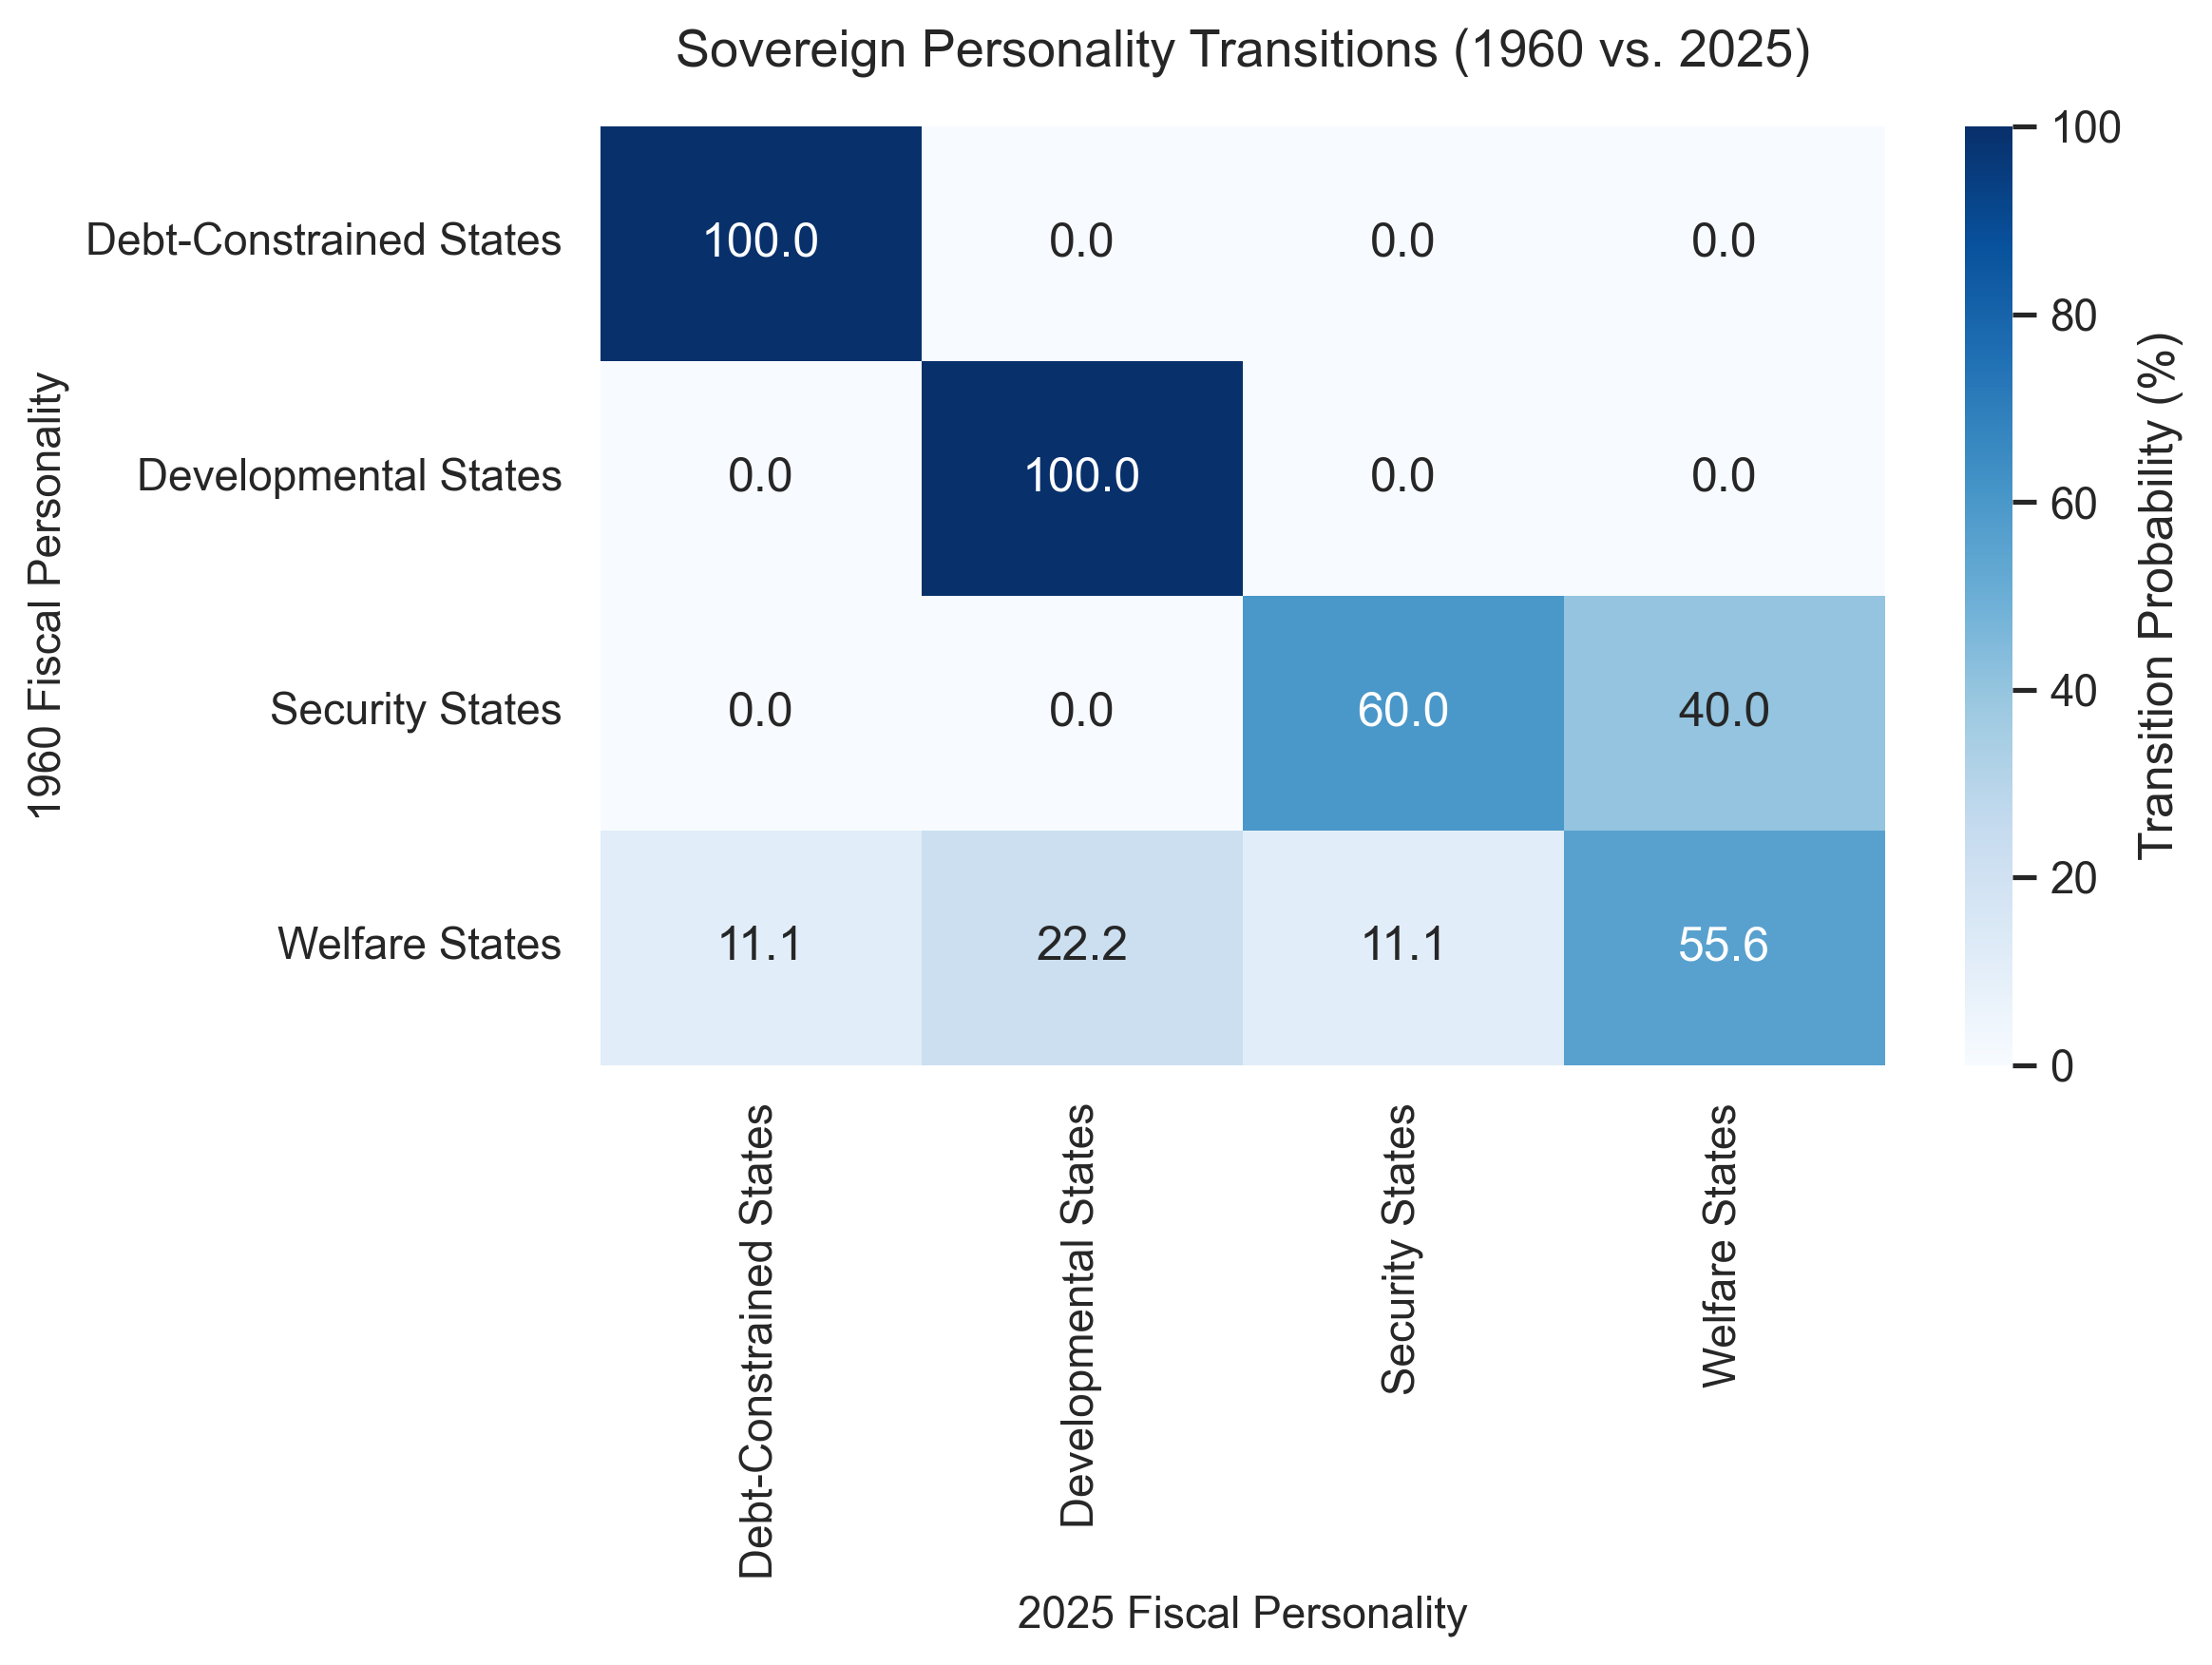

In [15]:
# Analyze how countries transition between personality types across 3 benchmark eras
# Eras: 1960 (Cold War), 1995 (Post-Cold War), 2025 (Modern Era)

benchmark_years = [1960, 1995, 2025]
df_transitions = df_cluster[df_cluster['Year'].isin(benchmark_years)].pivot(
    index='Country', 
    columns='Year', 
    values='Fiscal_Personality'
).dropna()

print(f"Tracking transitions across {len(df_transitions)} countries with full historical coverage:")
display(df_transitions.head(10))

# Compute a Transition Probability Matrix between 1960 and 2025
transition_matrix = pd.crosstab(
    df_transitions[1960], 
    df_transitions[2025], 
    normalize='index'
) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Transition Probability (%)'})
plt.title("Sovereign Personality Transitions (1960 vs. 2025)", fontsize=13, pad=15)
plt.xlabel("2025 Fiscal Personality", fontsize=11)
plt.ylabel("1960 Fiscal Personality", fontsize=11)
plt.tight_layout()

plt.savefig(PROJECT_ROOT / "outputs" / "04_transition_matrix.png")
plt.show()

# Export Final Clustered Parquet Dataset

In [16]:
# Save final dataset with cluster assignments
OUTPUT_CLUSTERED_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_clustered.parquet"
df_cluster.to_parquet(OUTPUT_CLUSTERED_PATH, index=False)

print(f"Clustered dataset saved to: {OUTPUT_CLUSTERED_PATH}")

Clustered dataset saved to: C:\Users\JYOTSNA\Documents\fiscal-ledger\data\processed\global_budgets_clustered.parquet
